<a href="https://colab.research.google.com/github/diegogr98/Diego-Gutierrez-Astronomy/blob/main/CCD_Camera_Characterization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<b>Nombre</b>: Diego Gutiérrez
<br>
<b>Objetivo:</b> Evaluar y caracterizar los parámetros operativos de una cámara CCD (ruido, ganancia, linealidad y sensibilidad).

## *Importando las imágenes flat y calculando el valor promedio de $\overline{F}_1$, $\overline{F}_2$* y $\sigma^2(\Delta_F)$


In [ ]:
import numpy as np
from astropy.io import fits
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import re
from collections import defaultdict

In [ ]:
import zipfile

zip_path1 = '/content/flats.zip'
extract_path = '/content/flats'

with zipfile.ZipFile(zip_path1, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Archivos extraídos a:", extract_path)

✅ Archivos extraídos a: /content/flats


In [ ]:
def parse_time_from_folder_path(path):
    """
    Extrae tiempo desde nombres como '.../0,1s/' y convierte '0,1' → 0.1
    """
    # Buscar nombres como '0,1s', '12,8s', etc.
    match = re.search(r'[/\\](\d+,\d+|\d+)s', path)
    if match:
        tiempo_str = match.group(1).replace(',', '.')
        try:
            return float(tiempo_str)
        except ValueError:
            return None
    return None

def combine_images(file_list):
    stack = []
    for f in file_list:
        data = fits.getdata(f)
        if np.isnan(data).any() or np.isinf(data).any():
            print(f"⚠️ {f} contiene NaN o Inf. Se omite.")
            continue
        stack.append(data)
    if len(stack) == 0:
        return None
    return np.mean(stack, axis=0)

def generar_grupos_flat_desde_subcarpetas(directorio='/content/flats',
                                          guardar_fits=True):
    flat_files = sorted(glob.glob(os.path.join(directorio, '**', '*.fit'),
                                  recursive=True))
    print(f"📁 Archivos .fit encontrados: {len(flat_files)}")

    grupos = defaultdict(list)
    for f in flat_files:
        t = parse_time_from_folder_path(f)
        if t is not None:
            grupos[t].append(f)
        else:
            print(f"❌ No se reconoció el tiempo en: {f}")

    resultados = {}

    for t, files in grupos.items():
        print(f"⏱️ t = {t}s → {len(files)} archivos")

        if len(files) < 2:
            continue

        mitad = len(files) // 2
        grupo1 = files[:mitad]
        grupo2 = files[mitad:]

        F1 = combine_images(grupo1)
        F2 = combine_images(grupo2)

        if F1 is None or F2 is None:
            print(f"❌ No se pudo combinar t = {t}")
            continue

        resultados[t] = {'F1': F1, 'F2': F2}

        if guardar_fits:
            fits.writeto(f'/content/F1_{str(t).replace(".", "p")}s.fits',
                         F1, overwrite=True)
            fits.writeto(f'/content/F2_{str(t).replace(".", "p")}s.fits',
                         F2, overwrite=True)

    print(f"✅ Combinación completada para {len(resultados)} tiempos.")
    return resultados

In [ ]:
resultados = generar_grupos_flat_desde_subcarpetas('/content/flats')

# Inicializar listas
tiempos = []
media_F1 = []
media_F2 = []
var_delta_F = []

for t in sorted(resultados.keys()):
    F1 = resultados[t]['F1']
    F2 = resultados[t]['F2']

    if F1 is None or F2 is None:
        continue

    mF1 = np.mean(F1)
    mF2 = np.mean(F2)
    sF1 = np.std(F1)
    sF2 = np.std(F2)
    diff = F1 - F2
    var_diff = np.var(diff)

    if var_diff == 0:
        print(f"⚠️ Varianza nula en t = {t}s, se omite.")
        continue

    # Almacenar
    tiempos.append(t)
    media_F1.append(mF1)
    media_F2.append(mF2)
    var_delta_F.append(var_diff)

# Convertir a arrays NumPy
tiempos = np.array(tiempos)
media_F1 = np.array(media_F1)
media_F2 = np.array(media_F2)
var_delta_F = np.array(var_delta_F)

📁 Archivos .fit encontrados: 225
⏱️ t = 0.05s → 20 archivos
⏱️ t = 0.1s → 20 archivos
⏱️ t = 0.2s → 20 archivos
⏱️ t = 0.4s → 20 archivos
⏱️ t = 0.8s → 20 archivos
⏱️ t = 1.6s → 20 archivos
⏱️ t = 102.4s → 10 archivos
⏱️ t = 12.8s → 20 archivos
⏱️ t = 204.8s → 4 archivos
⏱️ t = 25.6s → 20 archivos
⏱️ t = 3.2s → 20 archivos
⏱️ t = 500.0s → 1 archivos
⏱️ t = 51.2s → 10 archivos
⏱️ t = 6.4s → 20 archivos
✅ Combinación completada para 13 tiempos.


In [ ]:
print("Tiempos procesados:", sorted(resultados.keys()))

Tiempos procesados: [0.05, 0.1, 0.2, 0.4, 0.8, 1.6, 3.2, 6.4, 12.8, 25.6, 51.2, 102.4, 204.8]


## *Importando las imágenes Bias y calculando el valor promedio de $\overline{B}_1$, $\overline{B}_2$* y $\sigma^2(\Delta_B)$

In [ ]:
def combinar_bias(directorio_bias='/content/bias'):
    # Buscar archivos tipo image1B.fit, image2B.fit, etc.
    archivos_bias = sorted(glob.glob(os.path.join(directorio_bias,
                                                  'image*B.fit')))
    print(f"🧾 Se encontraron {len(archivos_bias)} archivos bias.")

    if len(archivos_bias) < 2:
        print("❌ No hay suficientes imágenes bias.")
        return None

    mitad = len(archivos_bias) // 2
    grupo1 = archivos_bias[:mitad]
    grupo2 = archivos_bias[mitad:]

    def combinar(files):
        stack = [fits.getdata(f) for f in files]
        return np.mean(stack, axis=0)

    B1 = combinar(grupo1)
    B2 = combinar(grupo2)

    delta_B = B1 - B2
    sigma_delta_B = np.std(delta_B)

    print(f"✅ Combinación realizada.")
    print(f"   σ(ΔB) = {sigma_delta_B:.2f} ADU")

    return {
        'B1': B1,
        'B2': B2,
        'delta_B': delta_B,
        'sigma_delta_B': sigma_delta_B,
        'archivos_grupo1': grupo1,
        'archivos_grupo2': grupo2
    }

In [ ]:
zip_path2 = '/content/Bias.zip'  # cambia este nombre si es distinto
extract_path = '/content/bias'

with zipfile.ZipFile(zip_path2, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
def obtener_parametros_bias(directorio_bias='/content/bias'):
    # Buscar imágenes bias
    archivos_bias = sorted(glob.glob(os.path.join(directorio_bias,
                                                  'Image*B.fit')))
    print(f"🧾 Se encontraron {len(archivos_bias)} archivos bias.")

    if len(archivos_bias) < 2:
        print("❌ No hay suficientes imágenes bias.")
        return None

    mitad = len(archivos_bias) // 2
    grupo1 = archivos_bias[:mitad]
    grupo2 = archivos_bias[mitad:]

    # Combinar imágenes por grupo
    stack_B1 = np.array([fits.getdata(f) for f in grupo1])
    stack_B2 = np.array([fits.getdata(f) for f in grupo2])

    B1 = np.mean(stack_B1, axis=0)
    B2 = np.mean(stack_B2, axis=0)

    # Cálculos globales necesarios
    media_B1 = np.mean(B1)
    media_B2 = np.mean(B2)
    delta_B = B1 - B2
    var_delta_B = np.var(delta_B)

    print(f"✅ Bias procesado:")
    print(f"   Media B1: {media_B1:.2f} ADU")
    print(f"   Media B2: {media_B2:.2f} ADU")
    print(f"   Varianza ΔB: {var_delta_B:.2f} (ADU)^2")

    return {
        'media_B1': media_B1,
        'media_B2': media_B2,
        'var_delta_B': var_delta_B
    }

In [ ]:
bias_stats = obtener_parametros_bias('/content/bias')

# Guardando los valores para las imagenes Bias:
media_B1 = bias_stats['media_B1']
media_B2 = bias_stats['media_B2']
var_delta_B = bias_stats['var_delta_B']

🧾 Se encontraron 20 archivos bias.
✅ Bias procesado:
   Media B1: 536.64 ADU
   Media B2: 536.93 ADU
   Varianza ΔB: 59.86 (ADU)^2


##*Calculando las ganancias y generando la tabla*

In [ ]:
# Calcular ganancia para cada tiempo
ganancias = []
for i in range(len(tiempos)):
    num = (media_F1[i] + media_F2[i]) - (media_B1 + media_B2)
    denom = var_delta_F[i] - var_delta_B
    if denom <= 0:
        G = np.nan  # evitar división por cero o resultados inválidos
        print(f"⚠️ Varianza negativa o nula en t = {tiempos[i]}s. Se omite.")
    else:
        G = num / denom
    ganancias.append(G)

ganancias = np.array(ganancias)

# Crear tabla con pandas
df = pd.DataFrame({
    'Tiempo de exposición (s)': tiempos,
    'Media Flat1': media_F1,
    'Media Flat2': media_F2,
    'Media B1': [media_B1] * len(tiempos),
    'Media B2': [media_B2] * len(tiempos),
    'Ganancia (e/ADU)': ganancias
})

# Mostrar tabla
df

,Tiempo de exposición (s),Media Flat1,Media Flat2,Media B1,Media B2,Ganancia (e/ADU)
0,0.05,544.280640,543.453369,536.635071,536.93158,12.103387
1,0.10,557.493103,561.019104,536.635071,536.93158,10.727736
2,0.20,592.953186,593.214905,536.635071,536.93158,8.844483
3,0.40,643.012695,635.789734,536.635071,536.93158,8.877936
4,0.80,854.254150,891.728394,536.635071,536.93158,6.309444
5,1.60,1367.654785,1324.880859,536.635071,536.93158,7.435263
6,3.20,2162.393555,2262.642090,536.635071,536.93158,3.788795
7,6.40,2324.833984,2298.119385,536.635071,536.93158,6.226772
8,12.80,5984.884766,6314.745117,536.635071,536.93158,3.911022
9,25.60,11991.336914,11493.938477,536.635071,536.93158,3.751790


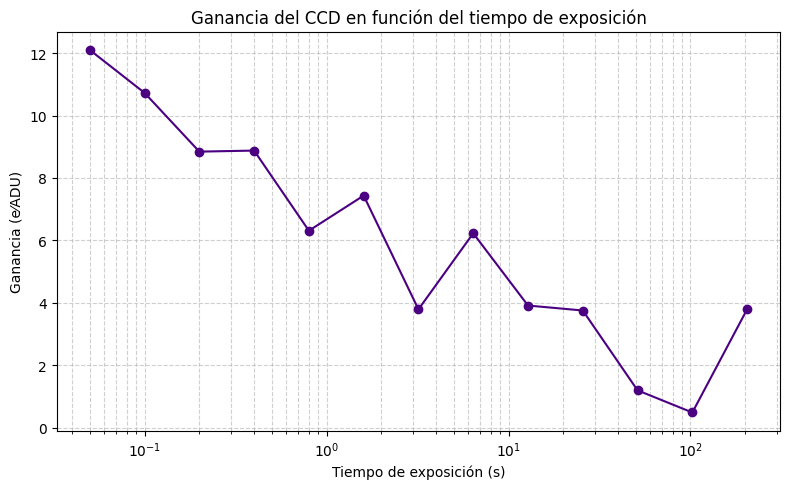

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(tiempos, ganancias, marker='o', linestyle='-', color='indigo')

plt.xscale('log')  # Escala logarítmica para el eje x
plt.xlabel("Tiempo de exposición (s)")
plt.ylabel("Ganancia (e⁄ADU)")
plt.title("Ganancia del CCD en función del tiempo de exposición")
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

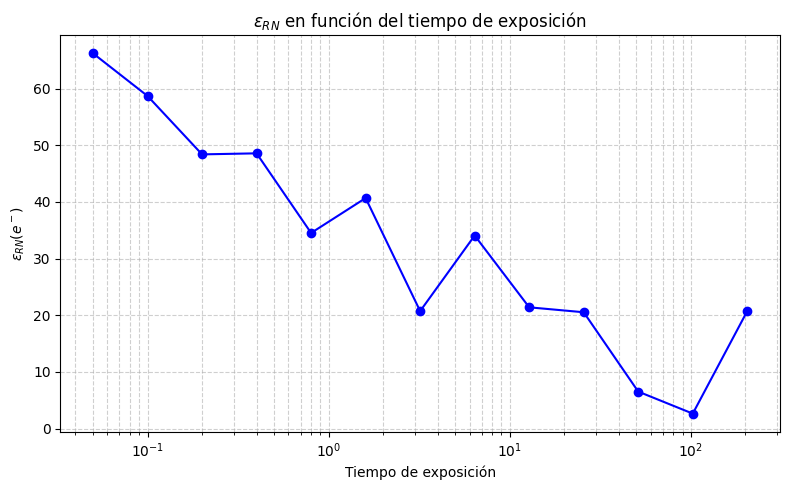

In [ ]:
# Cálculo de la desviación(Delta_B)
sigma_delta_B = np.sqrt(var_delta_B)

# Cálculo de epsilon_RN (Ruido de la cámara)
epsilon_RN = ganancias * (sigma_delta_B / np.sqrt(2))

# Gráfico
plt.figure(figsize=(8, 5))
plt.plot(tiempos, epsilon_RN, marker='o', linestyle='-', color='blue')
plt.xscale('log')  # Escala logarítmica para el eje x
plt.xlabel('Tiempo de exposición')
plt.ylabel(r'$\epsilon_{RN} (e^-)$')
plt.title(r'$\epsilon_{RN}$ en función del tiempo de exposición')
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# Promedio de Cuentas y desviación estándar de las imágenes Bias
b_prom = np.array([536.5, 537.2, 537.3, 537.3, 537.0, 536.0, 536.7, 533.2, 537.4, 537.8,
                   536.8, 537.8, 536.8, 535.2, 536.0, 537.1, 536.9, 537.5, 537.2, 537.8 ])

sigma_b = np.array([54.01,53.57,53.64,53.62,53.46,53.54,53.78,52.48,53.75,53.94,54.06,
                    53.81,53.8,53.35,53.65,53.29,53.21,53.51,53.65,53.11])


##*Analizando la linealidad*

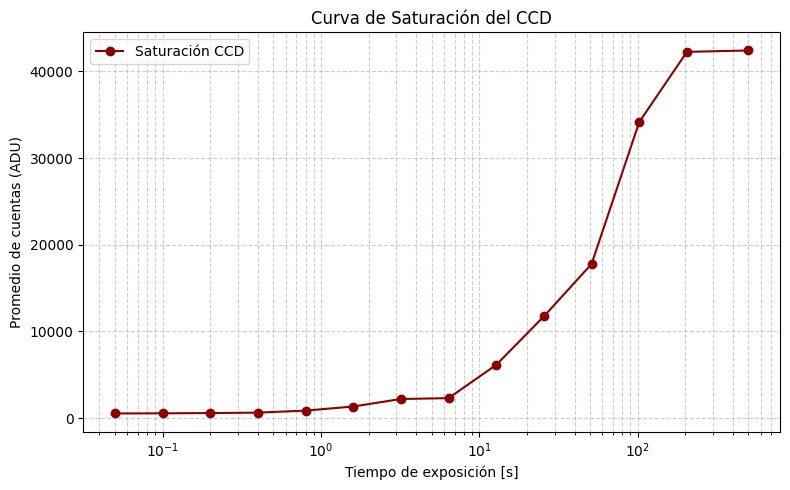

In [ ]:
F_prom = (media_F1 + media_F2)/2

F_prom1 = np.append(F_prom, 42400)
tiempos1 = np.append(tiempos, 500)

# Ahora graficando la saturación
plt.figure(figsize=(8, 5))
plt.plot(tiempos1, F_prom1, 'o-', color='darkred', label='Saturación CCD')
plt.xscale('log')  # Escala logarítmica para el eje x
plt.xlabel('Tiempo de exposición [s]')
plt.ylabel('Promedio de cuentas (ADU)')
plt.title('Curva de Saturación del CCD')
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

##*Pixeles muertos*

In [ ]:
def detectar_pixeles_muertos(directorio_bias='/content/bias', umbral_sigma=2.5, metodo='median'):
    archivos_bias = sorted(glob.glob(os.path.join(directorio_bias, 'Image*B.fit')))
    print(f"🧾 Archivos encontrados: {len(archivos_bias)}")

    if len(archivos_bias) < 2:
        print("❌ No hay suficientes imágenes bias.")
        return None, 0

    # Cargar imágenes bias
    stack = np.array([fits.getdata(f) for f in archivos_bias])

    # Combinar según el método
    if metodo == 'mean':
        bias_prom = np.mean(stack, axis=0)
    elif metodo == 'median':
        bias_prom = np.median(stack, axis=0)
    elif metodo == 'min':
        bias_prom = np.min(stack, axis=0)
    else:
        raise ValueError("Método no válido. Usa 'mean', 'median' o 'min'.")

    media_total = np.mean(bias_prom)
    std_total = np.std(bias_prom)

    # Umbral de detección
    umbral = media_total - umbral_sigma * std_total

    pixeles_muertos = bias_prom < umbral
    cantidad = np.sum(pixeles_muertos)

    print(f"🛠️ Método: {metodo}, Umbral: {umbral:.1f} ADU")
    print(f"🛠️ Píxeles muertos detectados: {cantidad}")

    return pixeles_muertos, cantidad

🧾 Archivos encontrados: 20
🛠️ Método: median, Umbral: 460.4 ADU
🛠️ Píxeles muertos detectados: 28355


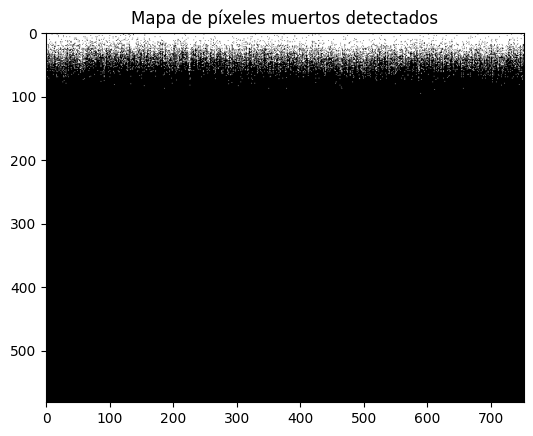

In [ ]:
pixeles_muertos, cantidad = detectar_pixeles_muertos(umbral_sigma=1.5, metodo='median')

plt.imshow(pixeles_muertos, cmap='gray')
plt.title('Mapa de píxeles muertos detectados')
plt.show()

In [ ]:
coordenadas = np.column_stack(np.where(pixeles_muertos))
np.savetxt("pixeles_muertos.csv", coordenadas, fmt='%d', delimiter=',',
           header="fila,columna", comments='')

🧾 Se encontraron 20 archivos superdark.
📉 Media: 536.78, σ: 50.84, Umbral: 455.43
🛠️ Píxeles muertos detectados: 16631


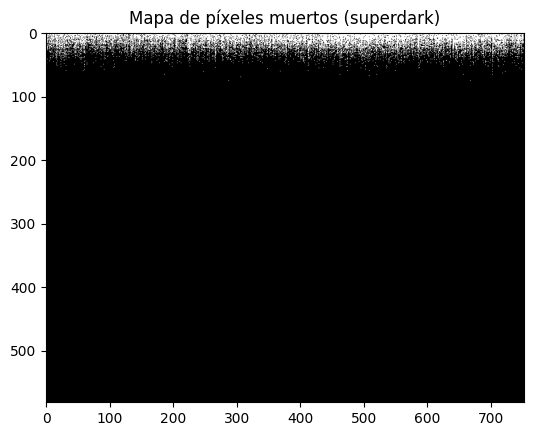

In [ ]:
# 1. Crear imagen promedio de superdarks
def obtener_superdark_prom(directorio='/content/darks'):
    archivos = sorted(glob.glob(os.path.join(directorio, 'Image*B.fit')))
    print(f"🧾 Se encontraron {len(archivos)} archivos superdark.")

    if len(archivos) == 0:
        print("❌ No se encontraron imágenes superdark.")
        return None

    stack = np.array([fits.getdata(f) for f in archivos])
    dark_prom = np.mean(stack, axis=0)
    return dark_prom

# 2. Detección de píxeles muertos
def detectar_pixeles_muertos(imagen, umbral_sigma=1.6):
    media = np.mean(imagen)
    sigma = np.std(imagen)
    umbral = media - umbral_sigma * sigma
    pixeles_muertos = imagen < umbral

    print(f"📉 Media: {media:.2f}, σ: {sigma:.2f}, Umbral: {umbral:.2f}")
    print(f"🛠️ Píxeles muertos detectados: {np.sum(pixeles_muertos)}")
    return pixeles_muertos

# 3. Ejecutar el análisis con superdarks
superdark_prom = obtener_superdark_prom('/content/darks')
if superdark_prom is not None:
    pixeles_muertos_sd = detectar_pixeles_muertos(superdark_prom)

    # 4. Visualización
    plt.imshow(pixeles_muertos_sd, cmap='gray')
    plt.title("Mapa de píxeles muertos (superdark)")
    plt.show()


In [ ]:
# Cargar cualquier imagen del conjunto
archivo = sorted(glob.glob('/content/bias/Image*.fit'))[0]
datos = fits.getdata(archivo)
print(f"Resolución de la imagen: {datos.shape}")
print(f"Número total de píxeles: {datos.size}")

Resolución de la imagen: (582, 752)
Número total de píxeles: 437664
